In [1]:
# ================================
# 1. IMPORT LIBRARIES
# ================================
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, GRU, Dense

# ================================
# 2. LOAD DATASET
# ================================
data = pd.read_csv('merge-csv_all.csv')

print("Dataset Preview:")
print(data.head())

# ================================
# 3. PREPROCESSING
# ================================

# Select only required columns
data = data[['battery_current', 'battery_voltage', 'soc']]

# Handle missing values (if any)
data = data.dropna()

# Separate input & output
X = data[['battery_current', 'battery_voltage']]
y = data['soc']

# Normalize features
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# ================================
# 4. CREATE TIME SEQUENCES (IMPORTANT)
# ================================
def create_sequences(X, y, time_steps=10):
    Xs, ys = [], []
    for i in range(len(X) - time_steps):
        Xs.append(X[i:i+time_steps])
        ys.append(y.iloc[i+time_steps])
    return np.array(Xs), np.array(ys)

TIME_STEPS = 10
X_seq, y_seq = create_sequences(X_scaled, y, TIME_STEPS)

print("Shape of X:", X_seq.shape)   # (samples, time_steps, features)

# ================================
# 5. TRAIN-TEST SPLIT
# ================================
X_train, X_test, y_train, y_test = train_test_split(
    X_seq, y_seq, test_size=0.2, random_state=42
)

# ================================
# 6. LSTM MODEL
# ================================
lstm_model = Sequential()
lstm_model.add(LSTM(64, activation='tanh', input_shape=(TIME_STEPS, 2)))
lstm_model.add(Dense(32, activation='relu'))
lstm_model.add(Dense(1))

lstm_model.compile(optimizer='adam', loss='mse', metrics=['mae'])

print("\nTraining LSTM...")
lstm_model.fit(X_train, y_train, epochs=300, batch_size=32,
               validation_data=(X_test, y_test))

# ================================
# 7. GRU MODEL
# ================================
gru_model = Sequential()
gru_model.add(GRU(64, activation='tanh', input_shape=(TIME_STEPS, 2)))
gru_model.add(Dense(32, activation='relu'))
gru_model.add(Dense(1))

gru_model.compile(optimizer='adam', loss='mse', metrics=['mae'])

print("\nTraining GRU...")
gru_model.fit(X_train, y_train, epochs=300, batch_size=32,
              validation_data=(X_test, y_test))

# ================================
# 8. EVALUATION
# ================================

# Predictions
lstm_pred = lstm_model.predict(X_test)
gru_pred = gru_model.predict(X_test)

# Function for metrics
def evaluate(y_true, y_pred, name):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    print(f"\n{name} Results:")
    print("RMSE:", rmse)
    print("R2 Score:", r2)

evaluate(y_test, lstm_pred, "LSTM")
evaluate(y_test, gru_pred, "GRU")

Dataset Preview:
   time  battery_current  solarCurrent  solarVoltage  battery_voltage  \
0  0.01       -15.096965      7.982070     10.399423        10.296543   
1  0.02        -8.170800      7.966645     15.073413        10.288427   
2  0.03        -7.242734      7.979580     11.174100        10.287528   
3  0.04        -9.586996      7.976338     12.176999        10.290540   
4  0.05        -8.590332      7.974155     12.846950        10.289541   

   solar_power       soc  
0    87.517851  3.288201  
1   119.371074  3.288202  
2    87.843845  3.288204  
3    97.235892  3.288206  
4   101.749526  3.288209  
Shape of X: (16810, 10, 2)

Training LSTM...
Epoch 1/300


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


421/421 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - loss: 1224.7651 - mae: 29.0673 - val_loss: 856.6161 - val_mae: 25.4088
Epoch 2/300
421/421 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 847.4271 - mae: 25.2585 - val_loss: 858.0292 - val_mae: 25.4127
Epoch 3/300
421/421 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 847.9749 - mae: 25.2661 - val_loss: 858.1224 - val_mae: 25.4121
Epoch 4/300
421/421 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 848.3743 - mae: 25.2564 - val_loss: 861.4980 - val_mae: 25.4070
Epoch 5/300
421/421 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 844.9536 - mae: 25.2181 - val_loss: 808.8893 - val_mae: 24.7295
Epoch 6/300
421/421 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 836.7846 - mae: 25.0891 - val_loss: 852.0862 - val_mae: 25.3560
Epoch 7/300
421/421 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - loss: 770.0474 - mae: 23.8334 - val_loss: 797.7841 - val_mae: 24.0926
Epoch 8/300
421/421 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 307.2847 - mae: 13.3204 - val_loss: 97.8085 - val_mae: 6.0983
Epoch 9/300


Epoch 1/300


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


560/560 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - loss: 2499.5464 - val_loss: 1549.3571
Epoch 2/300
560/560 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 543.6471 - val_loss: 38.7975
Epoch 3/300
560/560 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 60.5630 - val_loss: 3.9955
Epoch 4/300
560/560 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 48.1494 - val_loss: 3.1542
Epoch 5/300
560/560 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 48.9389 - val_loss: 4.5779
Epoch 6/300
560/560 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 48.0962 - val_loss: 6.4022
Epoch 7/300
560/560 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 49.6441 - val_loss: 3.3900
Epoch 8/300
560/560 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 44.9303 - val_loss: 2.3645
Epoch 9/300
560/560 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 43.9604 - val_loss: 4.6416
Epoch 10/300
560/560 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 43.0346 - val_loss: 4.9479
Epoch 11/300
560/560 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 43.1208 - val_loss: 2.7694
Epoch 12/300
560/560 ━━━━━━━━━━━━━━

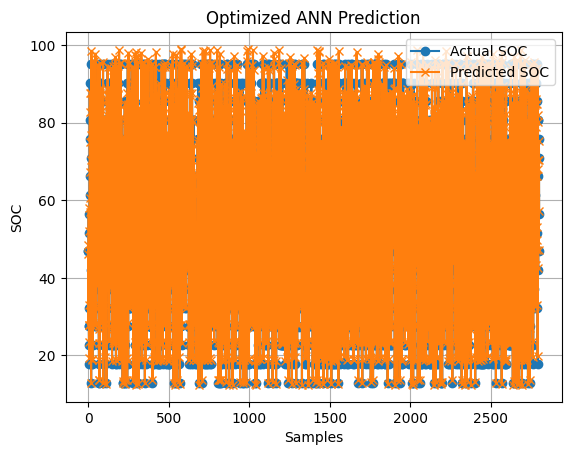

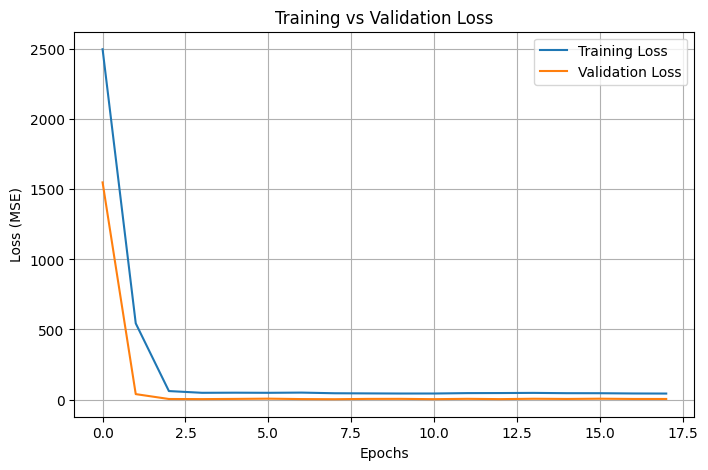

In [2]:
# ==========================================================
# OPTIMIZED ANN (MLP) REGRESSION - FINAL VERSION
# ==========================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# ==========================================================
# LOAD DATASET
# ==========================================================


data = pd.read_csv("merge-csv_all.csv")

# ==========================================================
# DATA CLEANING
# ==========================================================

data = data.drop_duplicates()
data = data.fillna(data.median(numeric_only=True))

# ==========================================================
# REMOVE OUTLIERS (IQR METHOD)
# ==========================================================

cols = ['battery_current', 'battery_voltage', 'soc']

for col in cols:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    data = data[(data[col] >= lower) & (data[col] <= upper)]

# ==========================================================
# FEATURES & TARGET
# ==========================================================

if 'soc_coulomb' in data.columns:
    X = data[['battery_current', 'battery_voltage', 'soc_coulomb']]
else:
    X = data[['battery_current', 'battery_voltage']]

y = data['soc']

# ==========================================================
# TRAIN-TEST SPLIT (BEFORE SCALING ✅)
# ==========================================================

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ==========================================================
# NORMALIZATION (NO DATA LEAKAGE ✅)
# ==========================================================

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ==========================================================
# BUILD OPTIMIZED MLP MODEL
# ==========================================================

model = Sequential([

    Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    BatchNormalization(),
    Dropout(0.3),

    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.2),

    Dense(32, activation='relu'),
    BatchNormalization(),

    Dense(1)
])

model.compile(
    optimizer='adam',
    loss='mse'
)

# ==========================================================
# CALLBACKS (VERY IMPORTANT)
# ==========================================================
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=300,
    batch_size=16,
    callbacks=[early_stop]
)


# ==========================================================
# TRAIN MODEL
# ==========================================================


# ==========================================================
# PREDICTION
# ==========================================================

pred = model.predict(X_test).flatten()

# ==========================================================
# METRICS
# ==========================================================

mse = mean_squared_error(y_test, pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, pred)

print("\n===== OPTIMIZED ANN RESULTS =====")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R2   : {r2:.4f}")

# ==========================================================
# PLOT 1: ACTUAL vs PREDICTED
# ==========================================================

plt.figure()
plt.plot(y_test.values, 'o-', label='Actual SOC')
plt.plot(pred, 'x-', label='Predicted SOC')
plt.legend()
plt.title('Optimized ANN Prediction')
plt.xlabel('Samples')
plt.ylabel('SOC')
plt.grid()
plt.show()
#==========================================================
import matplotlib.pyplot as plt

# ===============================
# LOSS CURVES
# ===============================
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("Training vs Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss (MSE)")
plt.legend()
plt.grid()

plt.show()
